In [1]:
import pandas as pd
import lifelines
import sklearn.preprocessing as skp
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from pathlib import Path

In [2]:
def fill_vals(df, column_name, exclude_values):
    # Create a copy of the dataframe
    df_copy = df.copy()

    # Exclude rows with specified values
    valid_data = df_copy[~df_copy[column_name].isin(exclude_values)]

    # Calculate the median
    median_value = valid_data[column_name].median()

    # Replace specified values with the median
    df_copy[column_name] = df_copy[column_name].replace({val: median_value for val in exclude_values})

    return df_copy

In [4]:
repo_root = Path.cwd()
while repo_root != repo_root.parent and not (repo_root / 'pyproject.toml').exists():
    repo_root = repo_root.parent

nhanes_dir = repo_root / 'data' / 'nhanes'
age_path = nhanes_dir / 'all_cohort_age_data.csv'
mortality_path = nhanes_dir / 'nhanes_mortality_all_years.csv'
sleep_path = nhanes_dir / 'sleep' / 'sleep_answers.csv'


mortality = pd.read_csv(mortality_path)
age = pd.read_csv(age_path)
sleep = pd.read_csv(sleep_path)



In [5]:
age_mortality_sleep = pd.merge(pd.merge(mortality, age, on='SEQN', how='outer'), sleep, on='SEQN', how='outer')

In [6]:
age_mortality_sleep = age_mortality_sleep.dropna(subset=['years_remaining'])
age_mortality_sleep = age_mortality_sleep.dropna(subset=['SLD010H'])
# round years_remaining column to the nearest integer
age_mortality_sleep['years_remaining'] = age_mortality_sleep['years_remaining'].round()

In [7]:
age_mortality_sleep['last_age'] = age_mortality_sleep.age_at_screening + age_mortality_sleep.years_remaining

In [8]:
for col in ['SLQ050', 'SLQ060']:
    age_mortality_sleep[col].fillna(0, inplace=True)

for col in ['SLQ070A', 'SLQ070B', 'SLQ070C', 'SLQ070D']:
    age_mortality_sleep[col].fillna(0, inplace=True)

for col in ['SLD010H', 'SLD020M']:
    age_mortality_sleep = fill_vals(age_mortality_sleep, col, [77, 99])

for col in ['SLQ030', 'SLQ040', 'SLQ050', 'SLQ060', 'SLQ070A', 'SLQ080', 'SLQ090', 'SLQ100', 'SLQ110', 'SLQ120', 'SLQ130', 'SLQ140', 'SLQ150', 'SLQ160']:
    age_mortality_sleep = fill_vals(age_mortality_sleep, col, [7, 9])

for col in ['SLQ170', 'SLQ180', 'SLQ190', 'SLQ200', 'SLQ210', 'SLQ220', 'SLQ230', 'SLQ240']:
    age_mortality_sleep = fill_vals(age_mortality_sleep, col, [1, 7, 9])

/var/folders/r5/2q8zzrr15ld3_jcs6mjrvk900000gn/T/ipykernel_44404/141224543.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  age_mortality_sleep[col].fillna(0, inplace=True)
/var/folders/r5/2q8zzrr15ld3_jcs6mjrvk900000gn/T/ipykernel_44404/141224543.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always

In [9]:
# Initialize the StandardScaler
standard_scaler = skp.StandardScaler()

age_mortality_sleep.SLD010H = abs(standard_scaler.fit_transform(age_mortality_sleep[['SLD010H']]))

In [10]:
# Select columns with 'SLQ' and 'SLD' in their names
columns_to_scale = [col for col in age_mortality_sleep.columns if 'SLQ' in col or 'SLD' in col]

# Initialize the MinMaxScaler
min_max_scaler = skp.MinMaxScaler()

# Fit and transform the selected columns
age_mortality_sleep[columns_to_scale] = min_max_scaler.fit_transform(age_mortality_sleep[columns_to_scale])

In [11]:
# Create a new column called sleep_frailty that averages the values of the columns with 'SLQ' and 'SLD' in their names
age_mortality_sleep['sleep_frailty'] = age_mortality_sleep[columns_to_scale].mean(axis=1)

In [13]:
age_mortality_sleep.SLQ030

31129    0.000000
31130    0.333333
31131    1.000000
31133    0.000000
31135    1.000000
           ...   
51617    0.000000
51618    0.666667
51619    1.000000
51621    0.000000
51622    0.333333
Name: SLQ030, Length: 11780, dtype: float64

In [12]:
# Create a density plot for sleep_frailty using plotly
frailty_prob = go.Figure(data=go.Histogram(x=age_mortality_sleep['sleep_frailty'], histnorm='probability'))
frailty_prob.update_layout(
    title='Probability of Sleep Frailty',
    xaxis_title='Sleep Frailty',
    yaxis_title='Probability',
    plot_bgcolor='white',
    paper_bgcolor='white'
)
frailty_prob.show()

In [13]:
import plotly.graph_objects as go

# Group by age_at_screening and calculate the mean of sleep_frailty
grouped_data = age_mortality_sleep.groupby('age_at_screening')['sleep_frailty'].mean()

# Create the original trace
original_trace = go.Scatter(
    x=grouped_data.index,
    y=grouped_data,
    mode='lines',
    name='Mean frailty',
    opacity=0.3
)

# Create the smoothed trace with a rolling window of 5
smoothed_trace = go.Scatter(
    x=grouped_data.index,
    y=grouped_data.rolling(window=5).mean(),
    mode='lines',
    name='Smoothed (window=5)'
)

# Create the figure and add the traces
fig = go.Figure()
fig.add_trace(original_trace)
fig.add_trace(smoothed_trace)

# Update the layout
fig.update_layout(
    title='Sleep Frailty by Age',
    xaxis_title='Age',
    yaxis_title='Sleep Frailty',
    legend_title='Legend',
    plot_bgcolor='white',
    paper_bgcolor='white'
)

# Show the plot
fig.show()

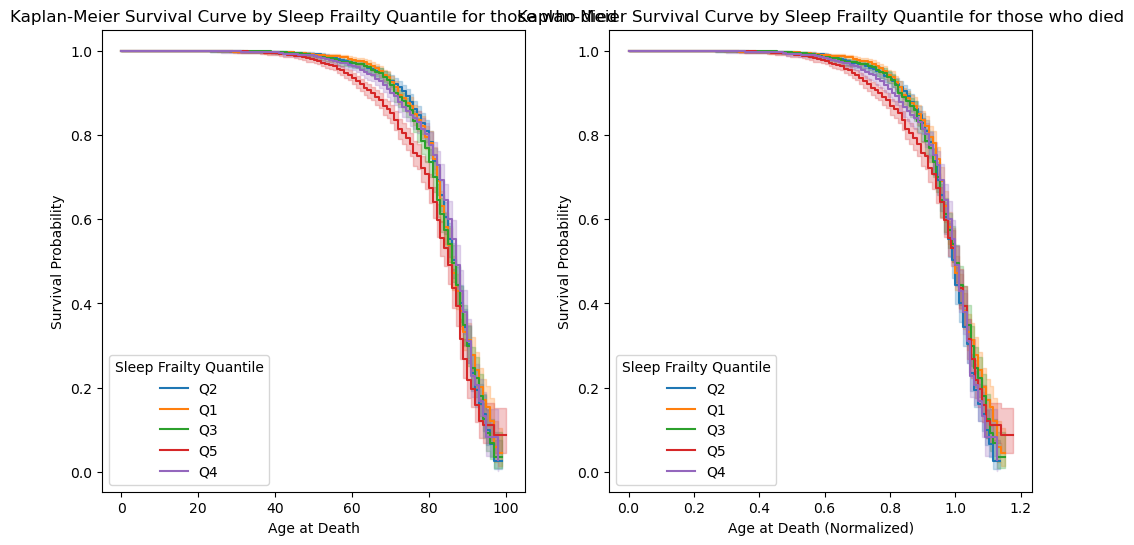

In [14]:
# Initialize the KaplanMeierFitter
kmf = lifelines.KaplanMeierFitter()

# Calculate the quantiles for the sleep_frailty column
quantiles = age_mortality_sleep['sleep_frailty'].quantile([0.2,0.4, 0.6, 0.8])

# Create a new column to categorize the data based on these quantiles
age_mortality_sleep['sleep_frailty_quantile'] = pd.cut(age_mortality_sleep['sleep_frailty'],
                                                       bins=[-float('inf'), quantiles[0.2],quantiles[0.4], quantiles[0.6], quantiles[0.8], float('inf')],
                                                       labels=['Q1', 'Q2', 'Q3', 'Q4','Q5'])

# # Initialize the figure and the axes
# fig, ax = plt.subplots()

# # Iterate over the sleep_frailty quantiles
# for quantile in age_mortality_sleep['sleep_frailty_quantile'].unique():
#     # Get the data for the current quantile
#     data = age_mortality_sleep[age_mortality_sleep['sleep_frailty_quantile'] == quantile]

#     # Fit the data into the model
#     kmf.fit(durations=data['last_age'], event_observed=data['status'])

#     # Plot the KM curve
#     kmf.plot_survival_function(ax=ax, label=quantile)

# plt.title('Kaplan-Meier Survival Curve by Sleep Frailty Quantile')
# plt.xlabel('Age at Death')
# plt.ylabel('Survival Probability')
# plt.legend(title='Sleep Frailty Quantile')
# plt.show()

# # check at what age for each group the survival probability is 0.5
# for quantile in age_mortality_sleep['sleep_frailty_quantile'].unique():
#     data = age_mortality_sleep[age_mortality_sleep['sleep_frailty_quantile'] == quantile]
#     kmf.fit(durations=data['last_age'], event_observed=data['status'])
#     median_age = kmf.median_survival_time_
#     print(f'The median age for {quantile} is {median_age} years')

# # plot again the survival curve but normalize the x axis to the median age
# fig, ax = plt.subplots()
# for quantile in age_mortality_sleep['sleep_frailty_quantile'].unique():
#     data = age_mortality_sleep[age_mortality_sleep['sleep_frailty_quantile'] == quantile]
#     kmf.fit(durations=data['last_age']/(kmf.median_survival_time_), event_observed=data['status'])
#     kmf.plot_survival_function(ax=ax, label=quantile)

# plt.title('Kaplan-Meier Survival Curve by Sleep Frailty Quantile')
# plt.xlabel('Age at Death (Normalized to Median Age)')
# plt.ylabel('Survival Probability')
# plt.legend(title='Sleep Frailty Quantile')
# plt.show()

# plot in suplots this plot and next to it the same but with a normalized age axis. normalize by dividing the age axis by the meadion age per quantile. 
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
for quantile in age_mortality_sleep['sleep_frailty_quantile'].unique():
    data = age_mortality_sleep[age_mortality_sleep['sleep_frailty_quantile'] == quantile]
    kmf.fit(durations=data['last_age'], event_observed=data['status'])
    kmf.plot_survival_function(ax=ax[0], label=quantile)
    median_age = kmf.median_survival_time_
    kmf.fit(durations=data['last_age'] / median_age, event_observed=data['status'])
    kmf.plot_survival_function(ax=ax[1], label=quantile)
ax[0].set_title('Kaplan-Meier Survival Curve by Sleep Frailty Quantile for those who died')
ax[0].set_xlabel('Age at Death')
ax[0].set_ylabel('Survival Probability')
ax[0].legend(title='Sleep Frailty Quantile')
ax[1].set_title('Kaplan-Meier Survival Curve by Sleep Frailty Quantile for those who died')
ax[1].set_xlabel('Age at Death (Normalized)')
ax[1].set_ylabel('Survival Probability')
ax[1].legend(title='Sleep Frailty Quantile')
plt.show()

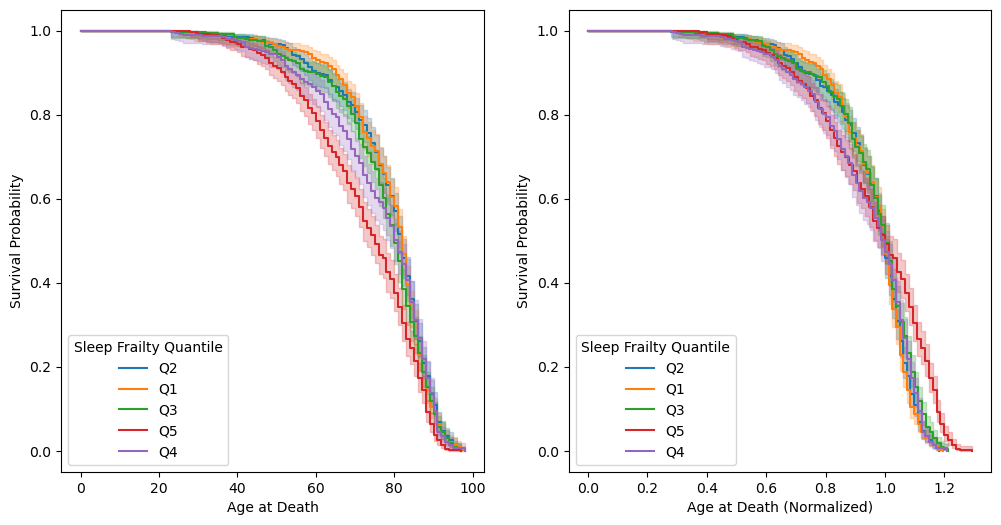

In [15]:
# take only the "status"==1 rows and plot the survival curve of those who died by quantiles:
age_mortality_sleep_died = age_mortality_sleep[age_mortality_sleep['status'] == 1]
# plot survivals curves like the previous code by quantiles:
# fig, ax = plt.subplots()
# for quantile in age_mortality_sleep['sleep_frailty_quantile'].unique():
#     data = age_mortality_sleep_died[age_mortality_sleep_died['sleep_frailty_quantile'] == quantile]
#     kmf.fit(durations=data['last_age'], event_observed=data['status'])
#     kmf.plot_survival_function(ax=ax, label=quantile)
# plt.title('Kaplan-Meier Survival Curve by Sleep Frailty Quantile for those who died')
# plt.xlabel('Age at Death')
# plt.ylabel('Survival Probability')
# plt.legend(title='Sleep Frailty Quantile')
# plt.show()

# plot in suplots this plot and next to it the same but with a normalized age axis. normalize by dividing the age axis by the meadion age per quantile. 
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
for quantile in age_mortality_sleep['sleep_frailty_quantile'].unique():
    data = age_mortality_sleep_died[age_mortality_sleep_died['sleep_frailty_quantile'] == quantile]
    kmf.fit(durations=data['last_age'], event_observed=data['status'])
    kmf.plot_survival_function(ax=ax[0], label=quantile)
    kmf.fit(durations=data['last_age'] / data['last_age'].median(), event_observed=data['status'])
    kmf.plot_survival_function(ax=ax[1], label=quantile)
#ax[0].set_title('Kaplan-Meier Survival Curve by Sleep Frailty Quantile for those who died')
ax[0].set_xlabel('Age at Death')
ax[0].set_ylabel('Survival Probability')
ax[0].legend(title='Sleep Frailty Quantile')
#ax[1].set_title('Kaplan-Meier Survival Curve by Sleep Frailty Quantile for those who died')
ax[1].set_xlabel('Age at Death (Normalized)')
ax[1].set_ylabel('Survival Probability')
ax[1].legend(title='Sleep Frailty Quantile')
plt.show()

/var/folders/lc/vd61xk_j2j739716llb8nhpc0000gp/T/ipykernel_54114/332630694.py:2: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



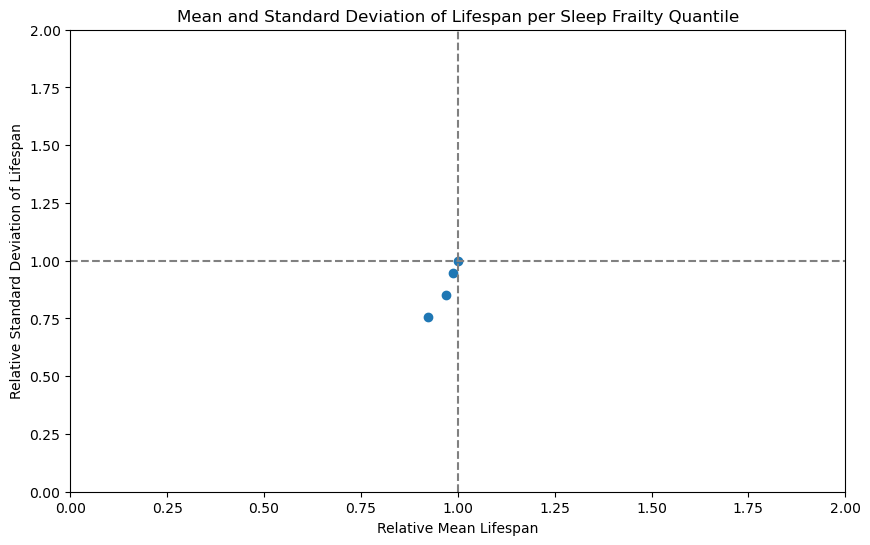

136


KeyboardInterrupt: 

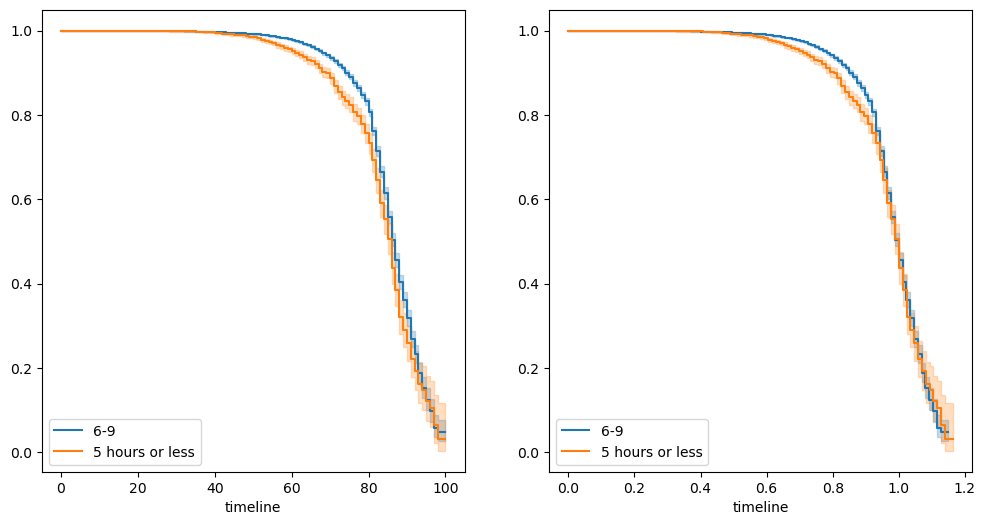

In [24]:
sleep_hours = pd.read_csv("sleep_hours.csv")
# merge the dataframes of mortality, age and sleep_hours. keep only rows that are in all dataframes based on thier identifier which is the SEQN column:
age_mortality_sleep_hours = pd.merge(pd.merge(mortality, age, on='SEQN', how='inner'), sleep_hours, on='SEQN', how='inner')
age_mortality_sleep_hours = age_mortality_sleep_hours.dropna(subset=['years_remaining'])
#age_mortality_sleep_hours = age_mortality_sleep_hours.dropna(subset=['SLD010H'])
age_mortality_sleep_hours['years_remaining'] = age_mortality_sleep_hours['years_remaining'].round()
age_mortality_sleep_hours['last_age'] = age_mortality_sleep_hours.age_at_screening + age_mortality_sleep_hours.years_remaining

# add a column that denotes if a patient slept less than 6 hours, 7-8 hours or more than 9 hours based on the "hours of sleep" column:
age_mortality_sleep_hours['sleep_hours_category'] = pd.cut(age_mortality_sleep_hours['hours_of_sleep'],
                                                           bins=[-float('inf'), 5, 9, float('inf')],
                                                           labels=['5 hours or less', '6-9', '10 hours or more'])
# check for nan values in the "hours_of_sleep" column:
print(age_mortality_sleep_hours['hours_of_sleep'].isnull().sum())
# remove the nan values from the "hours_of_sleep" column by removing the rows:
age_mortality_sleep_hours = age_mortality_sleep_hours.dropna(subset=['hours_of_sleep'])

# for category in age_mortality_sleep_hours['sleep_hours_category'].unique():
#     data = age_mortality_sleep_hours[age_mortality_sleep_hours['sleep_hours_category'] == category]
#     kmf = lifelines.KaplanMeierFitter()
#     kmf.fit(durations=data['last_age'], event_observed=data['status'])
#     kmf.plot_survival_function()
# plt.title('Kaplan-Meier Survival Curve for Patients who Slept 6 Hours or Less')
# plt.xlabel('Age at Death')
# plt.ylabel('Survival Probability')
# plt.show()

# plot next to the this plot another one with the age axis normalized by dividing the age axis by the median age at death per category:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
for category in age_mortality_sleep_hours['sleep_hours_category'].unique():
    data = age_mortality_sleep_hours[age_mortality_sleep_hours['sleep_hours_category'] == category]
    kmf = lifelines.KaplanMeierFitter()
    kmf.fit(durations=data['last_age'], event_observed=data['status'])
    kmf.plot_survival_function(ax=ax[0], label=category)
    median_age = kmf.median_survival_time_
    kmf.fit(durations=data['last_age'] / median_age, event_observed=data['status'])
    kmf.plot_survival_function(ax=ax[1], label=category)
#ax[0].set_title('Kaplan-Meier Survival Curve for Patients who Slept 6 Hours or Less')
ax[0].set_xlabel('Age at Death')
ax[0].set_ylabel('Survival Probability')
#ax[1].set_title('Kaplan-Meier Survival Curve for Patients who Slept 6 Hours or Less')
ax[1].set_xlabel('Age at Death (Normalized)')
ax[1].set_ylabel('Survival Probability')
plt.show()


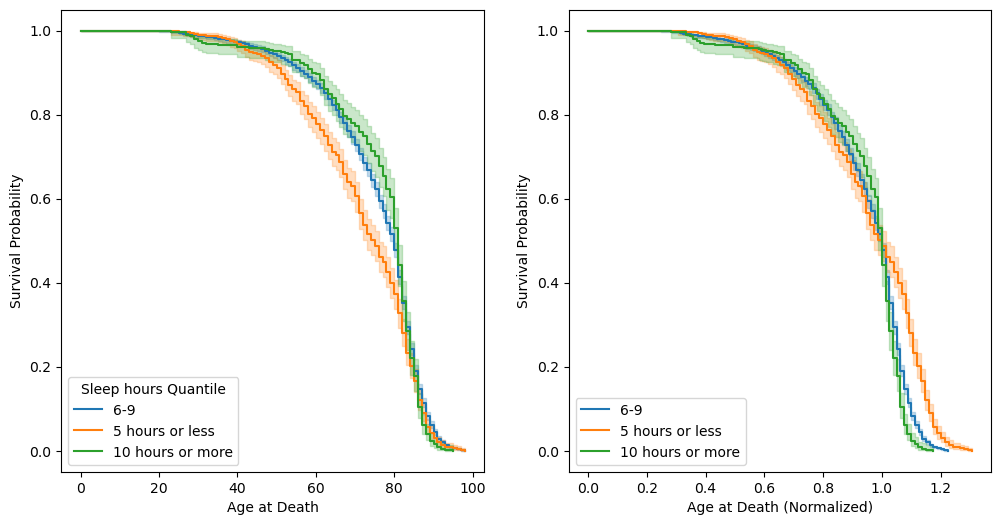

In [17]:
# take only the "status"==1 rows and plot the survival curve of those who died by quantiles:
age_mortality_sleep_hours_died = age_mortality_sleep_hours[age_mortality_sleep_hours['status'] == 1]
# plot survivals curves like the previous code by quantiles:
# fig, ax = plt.subplots()
# for quantile in age_mortality_sleep['sleep_frailty_quantile'].unique():
#     data = age_mortality_sleep_died[age_mortality_sleep_died['sleep_frailty_quantile'] == quantile]
#     kmf.fit(durations=data['last_age'], event_observed=data['status'])
#     kmf.plot_survival_function(ax=ax, label=quantile)
# plt.title('Kaplan-Meier Survival Curve by Sleep Frailty Quantile for those who died')
# plt.xlabel('Age at Death')
# plt.ylabel('Survival Probability')
# plt.legend(title='Sleep Frailty Quantile')
# plt.show()

# plot in suplots this plot and next to it the same but with a normalized age axis. normalize by dividing the age axis by the meadion age per quantile. 
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
for quantile in age_mortality_sleep_hours['sleep_hours_category'].unique():
    data = age_mortality_sleep_hours_died[age_mortality_sleep_hours_died['sleep_hours_category'] == quantile]
    kmf.fit(durations=data['last_age'], event_observed=data['status'])
    kmf.plot_survival_function(ax=ax[0], label=quantile)
    kmf.fit(durations=data['last_age'] / data['last_age'].median(), event_observed=data['status'])
    kmf.plot_survival_function(ax=ax[1], label=quantile)
#ax[0].set_title('Kaplan-Meier Survival Curve by Sleep Frailty Quantile for those who died')
ax[0].set_xlabel('Age at Death')
ax[0].set_ylabel('Survival Probability')
ax[0].legend(title='Sleep hours Quantile')
#ax[1].set_title('Kaplan-Meier Survival Curve by Sleep Frailty Quantile for those who died')
ax[1].set_xlabel('Age at Death (Normalized)')
ax[1].set_ylabel('Survival Probability')
ax[1].legend()
plt.show()

/var/folders/lc/vd61xk_j2j739716llb8nhpc0000gp/T/ipykernel_50268/889712365.py:4: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/var/folders/lc/vd61xk_j2j739716llb8nhpc0000gp/T/ipykernel_50268/889712365.py:10: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



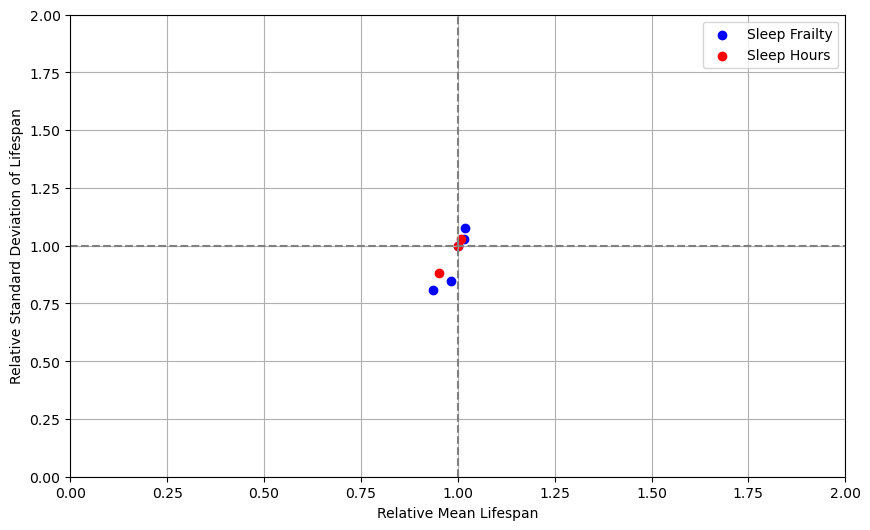

In [23]:
plt.figure(figsize=(10, 6))

# calculate the mean and std of the age at death for each quantile
lifespan_mean_std_per_quantile=age_mortality_sleep_died.groupby('sleep_frailty_quantile')['last_age'].agg(['mean', 'std'])
lifespan_mean_std_per_quantile["steepness"]=lifespan_mean_std_per_quantile["mean"]/lifespan_mean_std_per_quantile["std"]
# divide all rows by the first row:
relative_lifespan_mean_std_per_quantile=lifespan_mean_std_per_quantile/lifespan_mean_std_per_quantile.iloc[2]

# do the same for the sleep hours catagories:
lifespan_mean_std_per_category=age_mortality_sleep_hours_died.groupby('sleep_hours_category')['last_age'].agg(['mean', 'std'])
lifespan_mean_std_per_category["steepness"]=lifespan_mean_std_per_category["mean"]/lifespan_mean_std_per_category["std"]
# divide all rows by the first row:
relative_lifespan_mean_std_per_category=lifespan_mean_std_per_category/lifespan_mean_std_per_category.iloc[1]

# scatter the relative mean and std of the lifespan per quantile
plt.scatter(relative_lifespan_mean_std_per_quantile["mean"], relative_lifespan_mean_std_per_quantile["steepness"],label="Sleep Frailty",color="blue")
plt.scatter(relative_lifespan_mean_std_per_category["mean"], relative_lifespan_mean_std_per_category["steepness"],label="Sleep Hours",color="red")

# # calculate the mean and std of the age at death for each quantile
# lifespan_mean_std_per_quantile=age_mortality_sleep_died.groupby('sleep_frailty_quantile')['last_age'].agg(['mean', 'std'])
# lifespan_mean_std_per_quantile["steepness"]=lifespan_mean_std_per_quantile["mean"]/lifespan_mean_std_per_quantile["std"]
# # divide all rows by the first row:
# relative_lifespan_mean_std_per_quantile=lifespan_mean_std_per_quantile/lifespan_mean_std_per_quantile.iloc[0]

# # do the same for the sleep hours catagories:
# lifespan_mean_std_per_category=age_mortality_sleep_hours_died.groupby('sleep_hours_category')['last_age'].agg(['mean', 'std'])
# lifespan_mean_std_per_category["steepness"]=lifespan_mean_std_per_category["mean"]/lifespan_mean_std_per_category["std"]
# # divide all rows by the first row:
# relative_lifespan_mean_std_per_category=lifespan_mean_std_per_category/lifespan_mean_std_per_category.iloc[1]

# # scatter the relative mean and std of the lifespan per quantile
# plt.scatter(relative_lifespan_mean_std_per_quantile["mean"], relative_lifespan_mean_std_per_quantile["steepness"],color="blue")
# plt.scatter(relative_lifespan_mean_std_per_category["mean"], relative_lifespan_mean_std_per_category["steepness"],color="red")

plt.xlabel('Relative Mean Lifespan')
plt.ylabel('Relative Standard Deviation of Lifespan')
#plt.title('Mean and Standard Deviation of Lifespan per Sleep Frailty Quantile')
plt.xlim(0,2)
plt.ylim(0,2)
# add dashed line at x=1 and y=1
plt.axvline(1, color='gray', linestyle='--')
plt.axhline(1, color='gray', linestyle='--')
plt.legend()
plt.grid()
plt.show()

In [47]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
def simulate_onset_age_list(dt,eta,kappa,Xc,epsilon,beta):
    t_finals_list = []
    t_final = 250000
    num_iter = 1000
    x_of_all = []
    t_of_all = []
    for i in range(num_iter):
        new_t = 0
        new_x = 0
        x = [new_x]
        t = [new_t]
        while new_t<=t_final:
            # if x[-1]>0 or y[-1]>0:
            #     step_function=1
            # else:
            #     step_function=0
            new_x = x[-1] + (dt*((new_t)*eta - (beta*(x[-1]/(x[-1]+kappa)))) + np.sqrt(2*epsilon*dt)*np.random.randn())

            if new_x<0:
                new_x *= -1

            if new_x<Xc:
                x.append(new_x)
                t.append(new_t)
                new_t += dt
            else:
                new_x = Xc
                x.append(new_x)
                t.append(new_t)
                break
        #print(i,new_t,new_x)
        if i<4999:
            x_of_all.append(x)
            t_of_all.append(t)
        # if t[-1]<300:
        #     t[-1]=300
        # t_finals_list.append(t[-1]-300)
        t_finals_list.append(t[-1])
        # if len(t)>70:
        #     print("t larger than 70")
    #print("mean age of onset", np.mean(t_finals_list))
    return t_finals_list,x_of_all,t_of_all


def calculate_survival_curve(onset_times):
    # S(t) is the fraction of organisms that remain alive at time t
    all_ages_sorted = sorted(onset_times.iloc[:,0])
    age_counts = onset_times.value_counts().sort_index()
    N = len(all_ages_sorted)
    s_list = []
    people_alive_count = N
    age_axis = []
    for onset_age,count_occurrence in age_counts.items():
        s = people_alive_count/N
        s_list.append(s)
        people_alive_count -= count_occurrence
        age_axis.append(onset_age[0])
    return age_axis,s_list

def find_closest_and_corresponding(array1, array2, target=0.5):
    """
    Find the index where array1 has a value closest to target,
    and return that index, the closest value, and the corresponding value from array2.
    
    Parameters:
    array1: list/array of numbers to search in
    array2: list/array of corresponding values
    target: number to find closest value to (default 50)
    
    Returns:
    tuple: (index, closest_value, corresponding_value)
    """
    if len(array1) != len(array2):
        raise ValueError("Arrays must be of equal length")
    if not array1:
        raise ValueError("Arrays cannot be empty")
        
    # Find index of value closest to target
    closest_idx = min(range(len(array1)), key=lambda i: abs(array1[i] - target))
    
    return (
        closest_idx,
        array1[closest_idx],
        array2[closest_idx]
    )

# Function to simulate and calculate steepness and median age of onset
def simulate_and_calculate(params):
    sim_result = simulate_onset_age_list(1, params["eta"], params["kappa"], params["Xc"], params["epsilon"], params["beta"])
    list_of_ages_onset = sim_result[0]
    mean_age_of_onset = np.mean(list_of_ages_onset)
    survival_result = calculate_survival_curve(pd.DataFrame(list_of_ages_onset))
    index, closest, median_age_of_onset = find_closest_and_corresponding(survival_result[1], survival_result[0])
    steepness = np.mean(list_of_ages_onset) / np.std(list_of_ages_onset)
    return mean_age_of_onset, steepness

baseline_params = {"eta": 0.00135/365,"kappa": 0.5,"Xc":17 ,"epsilon":0.142 ,"beta":0.15 }
# Calculate baseline values
baseline_mean_age, baseline_steepness = simulate_and_calculate(baseline_params)
# # plot survival curve for the baseline parameters:
# sim_result = simulate_onset_age_list(1, baseline_params["eta"], baseline_params["kappa"], baseline_params["Xc"], baseline_params["epsilon"], baseline_params["beta"])
# age_axis,s_list = calculate_survival_curve(pd.DataFrame(sim_result[0]))
# plt.scatter(age_axis,s_list)
# plt.show()

# Number of iterations
# num_iterations = 3
# variation_range = [0.2,0.5,0.8,1,1.2,1.5,1.8]
# # Plot the trajectories for each parameter
# plt.figure(figsize=(10, 6))
# for param in baseline_params.keys():
#     all_median_ages = []
#     all_steepnesses = []
#     for factor in variation_range:
#         median_ages = []
#         steepnesses = []
#         for _ in range(num_iterations):
#             params = baseline_params.copy()
#             params[param] *= factor
#             median_age_of_onset, steepness = simulate_and_calculate(params)
#             median_ages.append(median_age_of_onset)
#             steepnesses.append(steepness)
#         all_median_ages.append(median_ages)
#         all_steepnesses.append(steepnesses)
    
#     mean_median_ages = np.mean(all_median_ages, axis=1)
#     std_median_ages = np.std(all_median_ages, axis=1)
#     mean_steepnesses = np.mean(all_steepnesses, axis=1)
#     std_steepnesses = np.std(all_steepnesses, axis=1)
    
#     relative_median_ages = mean_median_ages / baseline_median_age
#     relative_steepnesses = mean_steepnesses / baseline_steepness
    
#     plt.errorbar(relative_median_ages, relative_steepnesses, xerr=std_median_ages / baseline_median_age, yerr=std_steepnesses / baseline_steepness, label=param, linewidth=2, capsize=5)
#     for i in range(0,len(median_ages)-1):
#         if i==0:
#             plt.arrow(median_ages[i],steepnesses[i],median_ages[i+1]-median_ages[i],steepnesses[i+1]-steepnesses[i],head_width=0.3, head_length=0.3)
# plt.legend()
# #plt.xlim(0,2)
# #plt.ylim(0,2)
# plt.xlabel('Relative median age of onset')
# plt.ylabel('Relative steepness (1/CV)')
# plt.grid(alpha=0.3)
# plt.axvline(x=1, color='k', linestyle='--')
# plt.axhline(y=1, color='k', linestyle='--')
# import seaborn as sns
# sns.despine()
# plt.tight_layout()
# plt.show()

In [77]:
def steepness_mean_age_for_variations_of_paramteres(baseline_params,baseline_mean_age,baseline_steepness):
    variation_range = [0.2,0.5,0.8,1,1.2,1.5,1.8]
    relative_mean_ages=np.zeros((len(variation_range),len(baseline_params.keys())))
    relative_steepness=np.zeros((len(variation_range),len(baseline_params.keys())))
    # Plot the trajectories for each parameter
    all_mean_ages = np.zeros((len(variation_range),len(baseline_params.keys())))
    all_steepnesses = np.zeros((len(variation_range),len(baseline_params.keys())))
    j=0
    for param in baseline_params.keys():
        i=0
        for factor in variation_range:
            params = baseline_params.copy()
            params[param] *= factor
            mean_age_of_onset, steepness = simulate_and_calculate(params)
            if factor==1:
                baseline_mean_age = mean_age_of_onset
                baseline_steepness = steepness
            all_mean_ages[i,j] = mean_age_of_onset
            all_steepnesses[i,j] = steepness
            i+=1

        relative_mean_ages[:,j]= all_mean_ages[:,j]/baseline_mean_age
        relative_steepness[:,j]= all_steepnesses[:,j]/baseline_steepness
        j+=1
    return relative_mean_ages,relative_steepness
    
    # plt.errorbar(relative_median_ages, relative_steepnesses, xerr=std_median_ages / baseline_median_age, yerr=std_steepnesses / baseline_steepness, label=param, linewidth=2, capsize=5)
    # for i in range(0,len(median_ages)-1):
    #     if i==0:
    #         plt.arrow(median_ages[i],steepnesses[i],median_ages[i+1]-median_ages[i],steepnesses[i+1]-steepnesses[i],head_width=0.3, head_length=0.3)
# for idx in range(len(baseline_params.keys())):
#     plt.plot(all_median_ages[:,idx], all_steepnesses[:,idx],label=list(baseline_params.keys())[idx])
# #plt.xlim(0,2)
# #plt.ylim(0,2)
# plt.xlabel('Relative median age of onset')
# plt.ylabel('Relative steepness (1/CV)')
# plt.grid(alpha=0.3)
# plt.axvline(x=1, color='k', linestyle='--')
# plt.axhline(y=1, color='k', linestyle='--')
# plt.tight_layout()
# plt.show()

In [78]:
list_all_mean_ages = []
list_all_steepnesses = []
for iter in range(3):
    all_mean_ages, all_steepnesses = steepness_mean_age_for_variations_of_paramteres(baseline_params,baseline_mean_age,baseline_steepness)
    list_all_mean_ages.append(all_mean_ages)
    list_all_steepnesses.append(all_steepnesses)
mean_mean_ages = np.mean(list_all_mean_ages, axis=0)
std_mean_ages = np.std(list_all_mean_ages, axis=0)
mean_steepness = np.mean(list_all_steepnesses,axis=0)
std_steepness = np.std(list_all_steepnesses,axis=0)

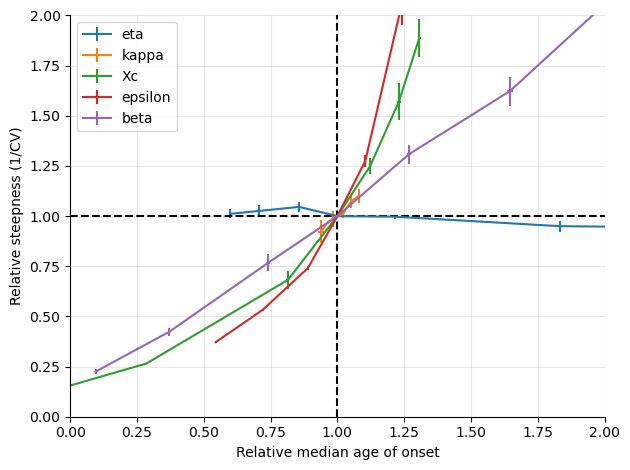

In [79]:
for param_idx in range(len(baseline_params.keys())):
    array_mean_mean_ages = mean_mean_ages[:,param_idx]
    array_std_mean_ages = std_mean_ages[:,param_idx]
    array_mean_steepness = mean_steepness[:,param_idx]
    array_std_steepness  = std_steepness[:,param_idx]
    #baseline_mean_age = array_mean_mean_ages[3]
    #baseline_steepness = array_mean_steepness[3]
    plt.errorbar(x=array_mean_mean_ages,y=array_mean_steepness,xerr=array_std_mean_ages,yerr=array_std_steepness,label=list(baseline_params.keys())[param_idx])
plt.xlim(0,2)
plt.ylim(0,2)
plt.xlabel('Relative median age of onset')
plt.ylabel('Relative steepness (1/CV)')
plt.grid(alpha=0.3)
plt.axvline(x=1, color='k', linestyle='--')
plt.axhline(y=1, color='k', linestyle='--')
plt.tight_layout()
plt.legend()
sns.despine()
plt.show()

/var/folders/lc/vd61xk_j2j739716llb8nhpc0000gp/T/ipykernel_99890/942483704.py:17: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/var/folders/lc/vd61xk_j2j739716llb8nhpc0000gp/T/ipykernel_99890/942483704.py:23: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/var/folders/lc/vd61xk_j2j739716llb8nhpc0000gp/T/ipykernel_99890/942483704.py:33: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/var/folders/lc/vd61xk_j2j739716llb8nhpc

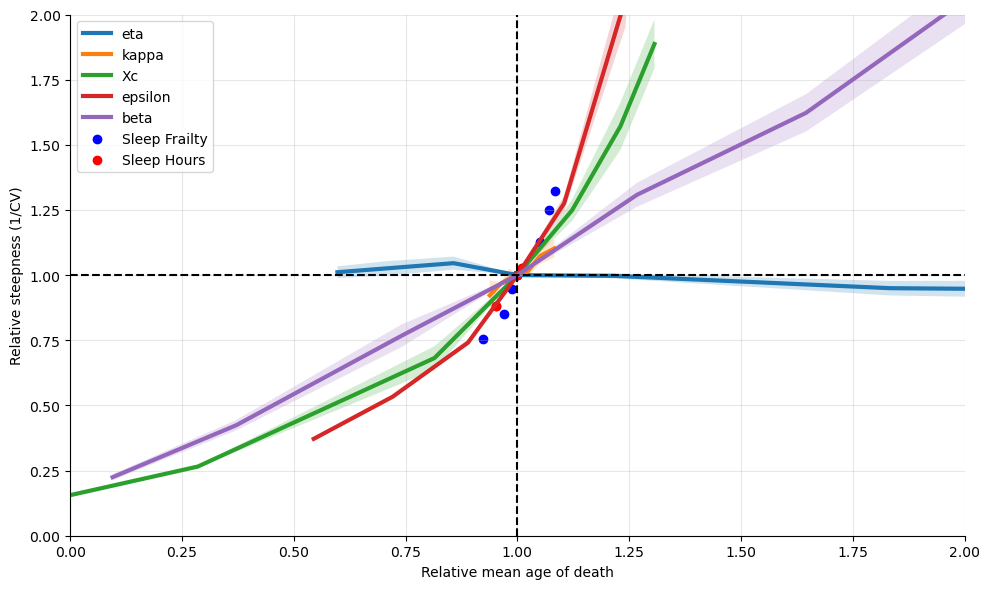

In [86]:
plt.figure(figsize=(10, 6))

for param_idx in range(len(baseline_params.keys())):
    array_mean_mean_ages = mean_mean_ages[:,param_idx]
    array_std_mean_ages = std_mean_ages[:,param_idx]
    array_mean_steepness = mean_steepness[:,param_idx]
    array_std_steepness  = std_steepness[:,param_idx]
    #baseline_mean_age = array_mean_mean_ages[3]
    #baseline_steepness = array_mean_steepness[3]
    #plt.errorbar(x=array_mean_mean_ages,y=array_mean_steepness,xerr=array_std_mean_ages,yerr=array_std_steepness,label=list(baseline_params.keys())[param_idx],linewidth=3)
    # Plot the line
    plt.plot(array_mean_mean_ages, array_mean_steepness, label=list(baseline_params.keys())[param_idx],linewidth=3)
    # Add the shadow (error region)
    plt.fill_between(array_mean_mean_ages, array_mean_steepness - array_std_steepness, array_mean_steepness + array_std_steepness, alpha=0.2)   

# calculate the mean and std of the age at death for each quantile
lifespan_mean_std_per_quantile=age_mortality_sleep_died.groupby('sleep_frailty_quantile')['last_age'].agg(['mean', 'std'])
lifespan_mean_std_per_quantile["steepness"]=lifespan_mean_std_per_quantile["mean"]/lifespan_mean_std_per_quantile["std"]
# divide all rows by the first row:
relative_lifespan_mean_std_per_quantile=lifespan_mean_std_per_quantile/lifespan_mean_std_per_quantile.iloc[3]

# do the same for the sleep hours catagories:
lifespan_mean_std_per_category=age_mortality_sleep_hours_died.groupby('sleep_hours_category')['last_age'].agg(['mean', 'std'])
lifespan_mean_std_per_category["steepness"]=lifespan_mean_std_per_category["mean"]/lifespan_mean_std_per_category["std"]
# divide all rows by the first row:
relative_lifespan_mean_std_per_category=lifespan_mean_std_per_category/lifespan_mean_std_per_category.iloc[1]

# scatter the relative mean and std of the lifespan per quantile
plt.scatter(relative_lifespan_mean_std_per_quantile["mean"], relative_lifespan_mean_std_per_quantile["steepness"],label="Sleep Frailty",color="blue")
plt.scatter(relative_lifespan_mean_std_per_category["mean"], relative_lifespan_mean_std_per_category["steepness"],label="Sleep Hours",color="red")

# calculate the mean and std of the age at death for each quantile
lifespan_mean_std_per_quantile=age_mortality_sleep_died.groupby('sleep_frailty_quantile')['last_age'].agg(['mean', 'std'])
lifespan_mean_std_per_quantile["steepness"]=lifespan_mean_std_per_quantile["mean"]/lifespan_mean_std_per_quantile["std"]
# divide all rows by the first row:
relative_lifespan_mean_std_per_quantile=lifespan_mean_std_per_quantile/lifespan_mean_std_per_quantile.iloc[0]

# do the same for the sleep hours catagories:
lifespan_mean_std_per_category=age_mortality_sleep_hours_died.groupby('sleep_hours_category')['last_age'].agg(['mean', 'std'])
lifespan_mean_std_per_category["steepness"]=lifespan_mean_std_per_category["mean"]/lifespan_mean_std_per_category["std"]
# divide all rows by the first row:
relative_lifespan_mean_std_per_category=lifespan_mean_std_per_category/lifespan_mean_std_per_category.iloc[1]

# scatter the relative mean and std of the lifespan per quantile
plt.scatter(relative_lifespan_mean_std_per_quantile["mean"], relative_lifespan_mean_std_per_quantile["steepness"],color="blue")
plt.scatter(relative_lifespan_mean_std_per_category["mean"], relative_lifespan_mean_std_per_category["steepness"],color="red")
plt.scatter(baseline_median_age, baseline_steepness,color="black",marker="*")

plt.xlim(0,2)
plt.ylim(0,2)
plt.xlabel('Relative mean age of death')
plt.ylabel('Relative steepness (1/CV)')
plt.grid(alpha=0.3)
plt.axvline(x=1, color='k', linestyle='--')
plt.axhline(y=1, color='k', linestyle='--')
plt.tight_layout()
plt.legend()
# reomove the top and right spines
sns.despine()
plt.show()